# 🌸 Iris Flower Classification — Phase 1: Exploratory Data Analysis
---
**Goal:** Deeply understand the dataset before touching any ML model.

**What you'll build:**
- Complete statistical profile of all 4 features
- Histogram + KDE plots per species
- Box plots with outlier detection
- Full pair plot (scatter matrix)
- Correlation heatmap
- Violin + jitter plots
- SVM decision boundary visualization
- Andrews Curves & RadViz separability analysis


## 1. Imports & Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from scipy.stats import gaussian_kde
from pandas.plotting import andrews_curves, radviz
import warnings
warnings.filterwarnings('ignore')

# ── Global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#2e3150',
    'axes.labelcolor':  '#e0e0f0',
    'xtick.color':      '#8888aa',
    'ytick.color':      '#8888aa',
    'text.color':       '#e0e0f0',
    'grid.color':       '#2e3150',
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
})

PALETTE  = ['#7c6af7', '#2fd6c8', '#f7736a']   # Setosa · Versicolor · Virginica
SPECIES  = ['Setosa', 'Versicolor', 'Virginica']
FEATURES = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
FEAT_LBL = ['Sepal Length (cm)', 'Sepal Width (cm)', 'Petal Length (cm)', 'Petal Width (cm)']

print('All imports OK ✓')

All imports OK ✓


## 2. Load Dataset


In [2]:
iris = load_iris()
df   = pd.DataFrame(iris.data, columns=FEATURES)
df['species'] = pd.Categorical.from_codes(iris.target, SPECIES)

print(f'Shape        : {df.shape}')
print(f'Null values  : {df.isnull().sum().sum()}')
print(f'Species dist :\n{df["species"].value_counts()}')
df.head(10)

Shape        : (150, 5)
Null values  : 0
Species dist :
species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
5,5.4,3.9,1.7,0.4,Setosa
6,4.6,3.4,1.4,0.3,Setosa
7,5.0,3.4,1.5,0.2,Setosa
8,4.4,2.9,1.4,0.2,Setosa
9,4.9,3.1,1.5,0.1,Setosa


## 3. Statistical Summary


In [3]:
# Overall stats
print('=== Overall Stats ===')
display(df.describe().round(2))

# Per-species stats
print('\n=== Mean per species ===')
display(df.groupby('species')[FEATURES].mean().round(2))

print('\n=== Std dev per species ===')
display(df.groupby('species')[FEATURES].std().round(2))

=== Overall Stats ===


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50



=== Mean per species ===


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Setosa,5.01,3.43,1.46,0.25
Versicolor,5.94,2.77,4.26,1.33
Virginica,6.59,2.97,5.55,2.03



=== Std dev per species ===


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Setosa,0.35,0.38,0.17,0.11
Versicolor,0.52,0.31,0.47,0.20
Virginica,0.64,0.32,0.55,0.27


## 4. Histograms + Box Plots


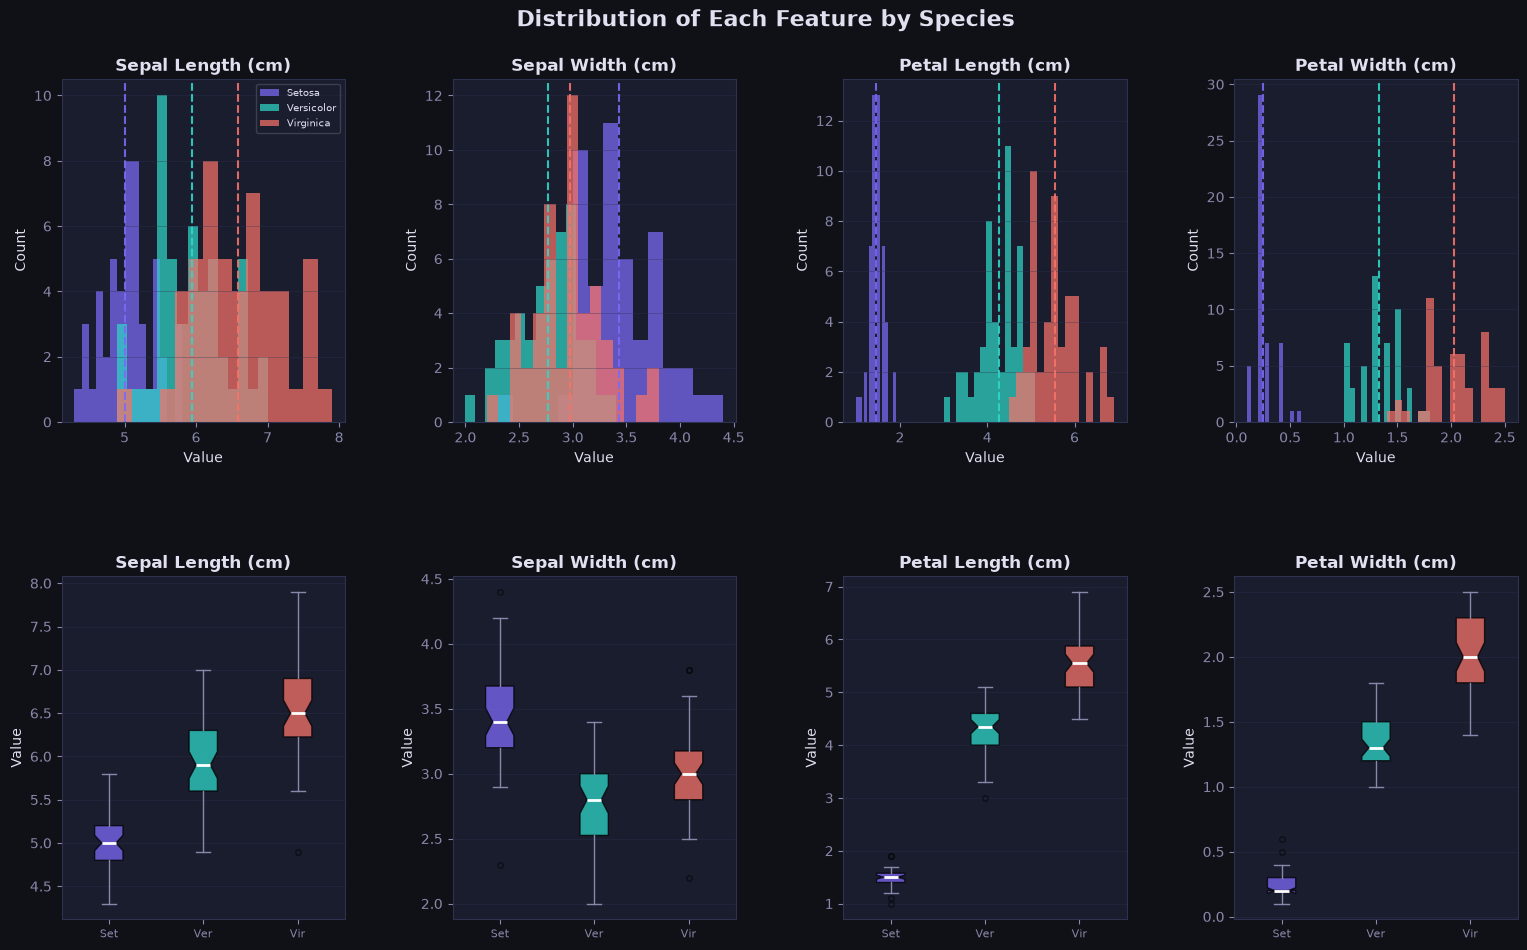

In [4]:
fig = plt.figure(figsize=(16, 10), facecolor='#0f1117')
fig.suptitle('Distribution of Each Feature by Species', fontsize=16,
             fontweight='bold', color='#e0e0f0', y=0.98)
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.38,
                       left=0.06, right=0.97, top=0.91, bottom=0.07)

# Row 0: histograms with mean lines
for i, (f, lbl) in enumerate(zip(FEATURES, FEAT_LBL)):
    ax = fig.add_subplot(gs[0, i])
    for sp, col in zip(SPECIES, PALETTE):
        vals = df[df['species']==sp][f]
        ax.hist(vals, bins=15, alpha=0.72, color=col, label=sp, edgecolor='none')
        ax.axvline(vals.mean(), color=col, linewidth=1.5, linestyle='--', alpha=0.9)
    ax.set_title(lbl, fontweight='bold', pad=6)
    ax.set_xlabel('Value'); ax.set_ylabel('Count')
    ax.grid(True, axis='y', alpha=0.4)
    if i == 0: ax.legend(fontsize=7, framealpha=0.2)

# Row 1: notched box plots
for i, (f, lbl) in enumerate(zip(FEATURES, FEAT_LBL)):
    ax = fig.add_subplot(gs[1, i])
    data_by_sp = [df[df['species']==sp][f].values for sp in SPECIES]
    bp = ax.boxplot(data_by_sp, patch_artist=True, notch=True,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#8888aa'),
                    capprops=dict(color='#8888aa'),
                    flierprops=dict(marker='o', markersize=4, alpha=0.5))
    for patch, col in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(col); patch.set_alpha(0.75)
    ax.set_xticks([1,2,3])
    ax.set_xticklabels(['Set','Ver','Vir'], fontsize=8)
    ax.set_title(lbl, fontweight='bold', pad=6)
    ax.set_ylabel('Value')
    ax.grid(True, axis='y', alpha=0.4)

plt.savefig('iris_01_overview.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
# KEY INSIGHT: Petal features show clear separation; sepal_width has most overlap.

## 5. Full Pair Plot (Scatter Matrix)
> **Key insight:** Petal length vs petal width is the best feature pair — nearly perfect linear separation of all three species.


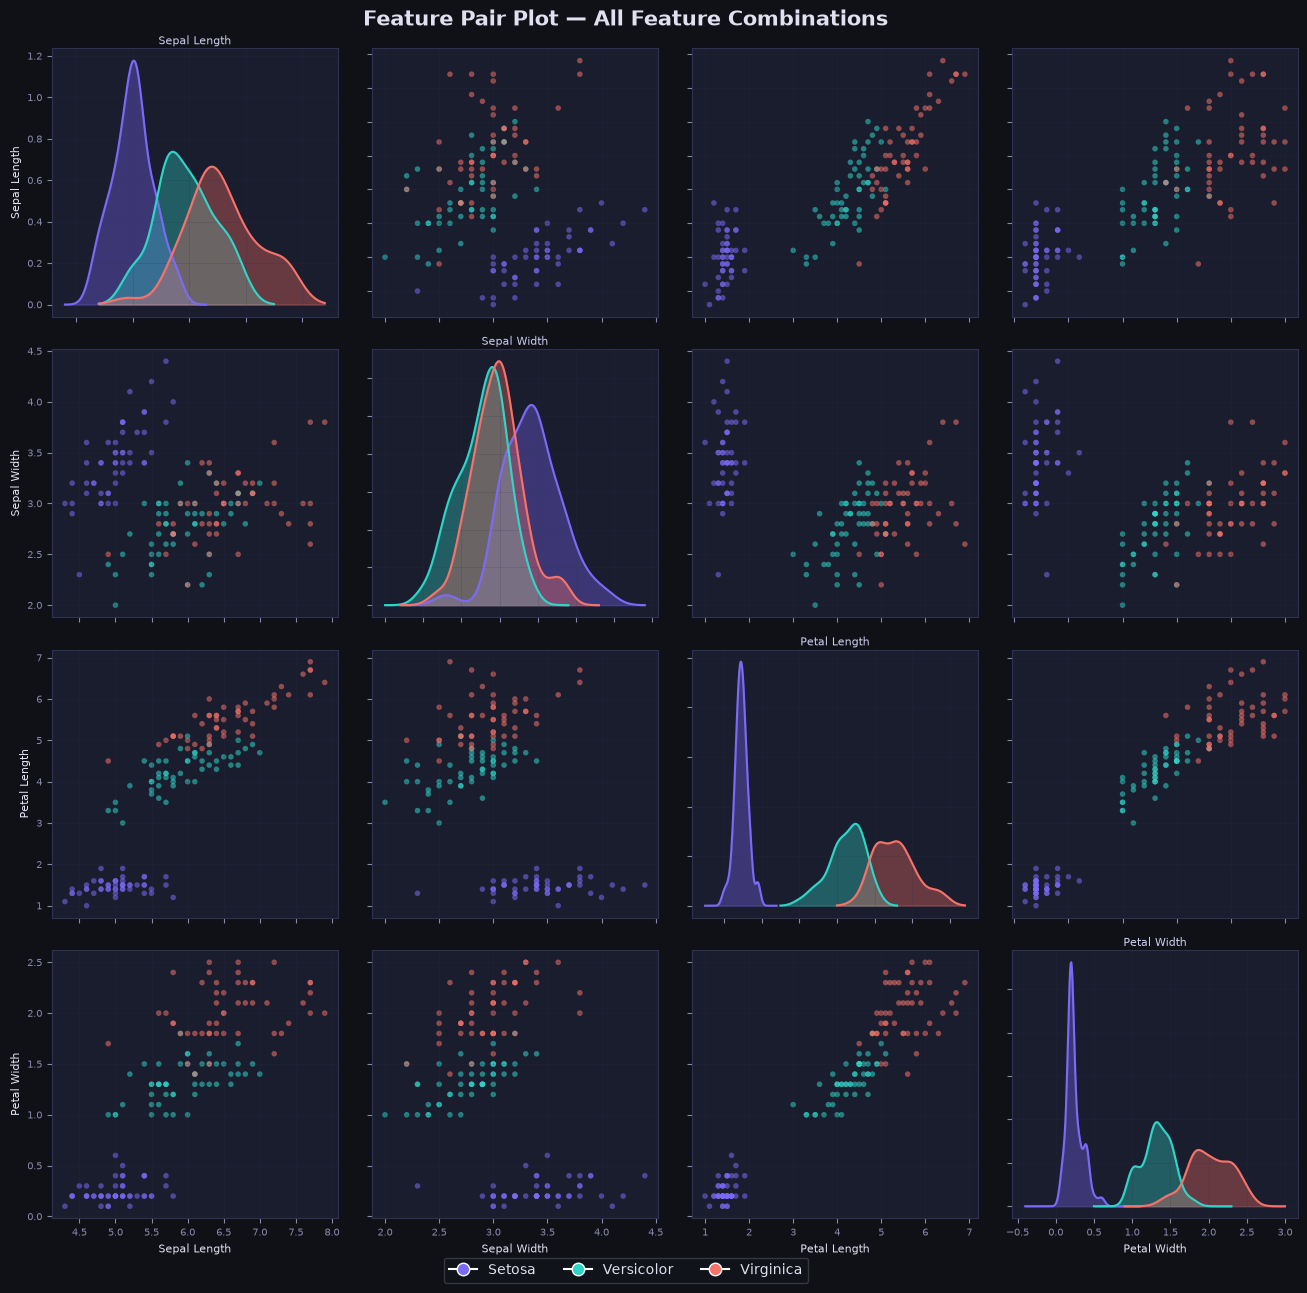

In [5]:
fig, axes = plt.subplots(4, 4, figsize=(14, 13), facecolor='#0f1117')
fig.suptitle('Feature Pair Plot — All Feature Combinations', fontsize=15,
             fontweight='bold', color='#e0e0f0', y=0.99)

for r in range(4):
    for c in range(4):
        ax = axes[r][c]
        ax.set_facecolor('#1a1d2e')
        for spine in ax.spines.values(): spine.set_edgecolor('#2e3150')
        if r == c:
            # Diagonal: KDE
            for sp, col in zip(SPECIES, PALETTE):
                vals = df[df['species']==sp][FEATURES[r]].values
                kde  = gaussian_kde(vals, bw_method=0.4)
                xs   = np.linspace(vals.min()-0.5, vals.max()+0.5, 200)
                ax.fill_between(xs, kde(xs), alpha=0.35, color=col)
                ax.plot(xs, kde(xs), color=col, linewidth=1.5)
            ax.set_title(FEAT_LBL[r].split(' (')[0], fontsize=8, color='#ccccee', pad=3)
        else:
            for sp, col in zip(SPECIES, PALETTE):
                sub = df[df['species']==sp]
                ax.scatter(sub[FEATURES[c]], sub[FEATURES[r]],
                           color=col, alpha=0.55, s=16, edgecolors='none')
        ax.tick_params(labelsize=7, colors='#8888aa')
        ax.grid(True, alpha=0.2)
        if c == 0: ax.set_ylabel(FEAT_LBL[r].split(' (')[0], fontsize=8)
        else: ax.set_yticklabels([])
        if r == 3: ax.set_xlabel(FEAT_LBL[c].split(' (')[0], fontsize=8)
        else: ax.set_xticklabels([])

handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=c,
           markersize=9, label=s) for s, c in zip(SPECIES, PALETTE)]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=10,
           framealpha=0.2, bbox_to_anchor=(0.5, 0.005))
plt.subplots_adjust(hspace=0.12, wspace=0.12, left=0.09, right=0.98, top=0.96, bottom=0.06)
plt.savefig('iris_02_pairplot.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 6. Correlation Heatmap + Violin Plots


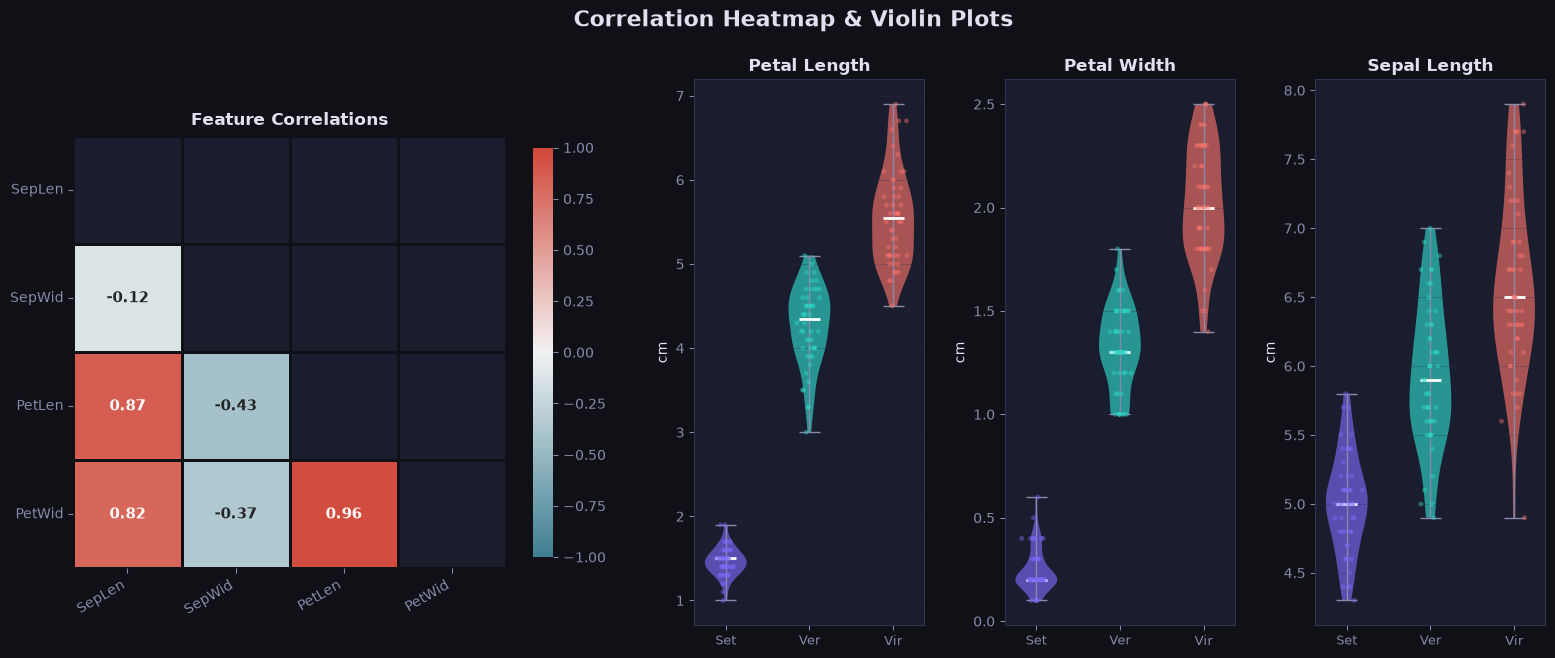

In [6]:
fig = plt.figure(figsize=(16, 7), facecolor='#0f1117')
gs  = gridspec.GridSpec(1, 5, figure=fig, wspace=0.35,
                        left=0.05, right=0.97, top=0.88, bottom=0.10)
fig.suptitle('Correlation Heatmap & Violin Plots', fontsize=16,
             fontweight='bold', color='#e0e0f0')

# Heatmap
ax_hm = fig.add_subplot(gs[0, :2])
corr  = df[FEATURES].corr()
mask  = np.triu(np.ones_like(corr, dtype=bool))
cmap  = sns.diverging_palette(220, 15, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size':11,'weight':'bold'},
            square=True, linewidths=1, linecolor='#0f1117',
            cbar_kws={'shrink':0.75}, ax=ax_hm)
ax_hm.set_title('Feature Correlations', fontweight='bold', pad=8)
ax_hm.set_xticklabels(['SepLen','SepWid','PetLen','PetWid'], rotation=30, ha='right')
ax_hm.set_yticklabels(['SepLen','SepWid','PetLen','PetWid'], rotation=0)

# Violin + jitter
violin_feats = ['petal_length','petal_width','sepal_length']
violin_lbls  = ['Petal Length','Petal Width','Sepal Length']
for j, (feat, title) in enumerate(zip(violin_feats, violin_lbls)):
    ax = fig.add_subplot(gs[0, j+2])
    ax.set_facecolor('#1a1d2e')
    data_v = [df[df['species']==sp][feat].values for sp in SPECIES]
    parts  = ax.violinplot(data_v, positions=[1,2,3], showmedians=True, showextrema=True)
    for body, col in zip(parts['bodies'], PALETTE):
        body.set_facecolor(col); body.set_alpha(0.65)
    parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2)
    for part in ['cbars','cmins','cmaxes']:
        parts[part].set_color('#8888aa'); parts[part].set_linewidth(1)
    for k, (sp, col) in enumerate(zip(SPECIES, PALETTE)):
        jx = np.random.normal(k+1, 0.055, size=50)
        ax.scatter(jx, df[df['species']==sp][feat].values,
                   color=col, alpha=0.45, s=12, zorder=3, edgecolors='none')
    ax.set_xticks([1,2,3])
    ax.set_xticklabels(['Set','Ver','Vir'], fontsize=9)
    ax.set_title(title, fontweight='bold', pad=6)
    ax.set_ylabel('cm'); ax.grid(True, axis='y', alpha=0.35)

plt.savefig('iris_03_corr_violin.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
# petal_length & petal_width: r=0.96 (near-perfect positive correlation)

## 7. Decision Boundary (SVM Preview)
> This gives you a taste of Phase 2. SVM with RBF kernel draws the decision regions using only the 2 most discriminative features.


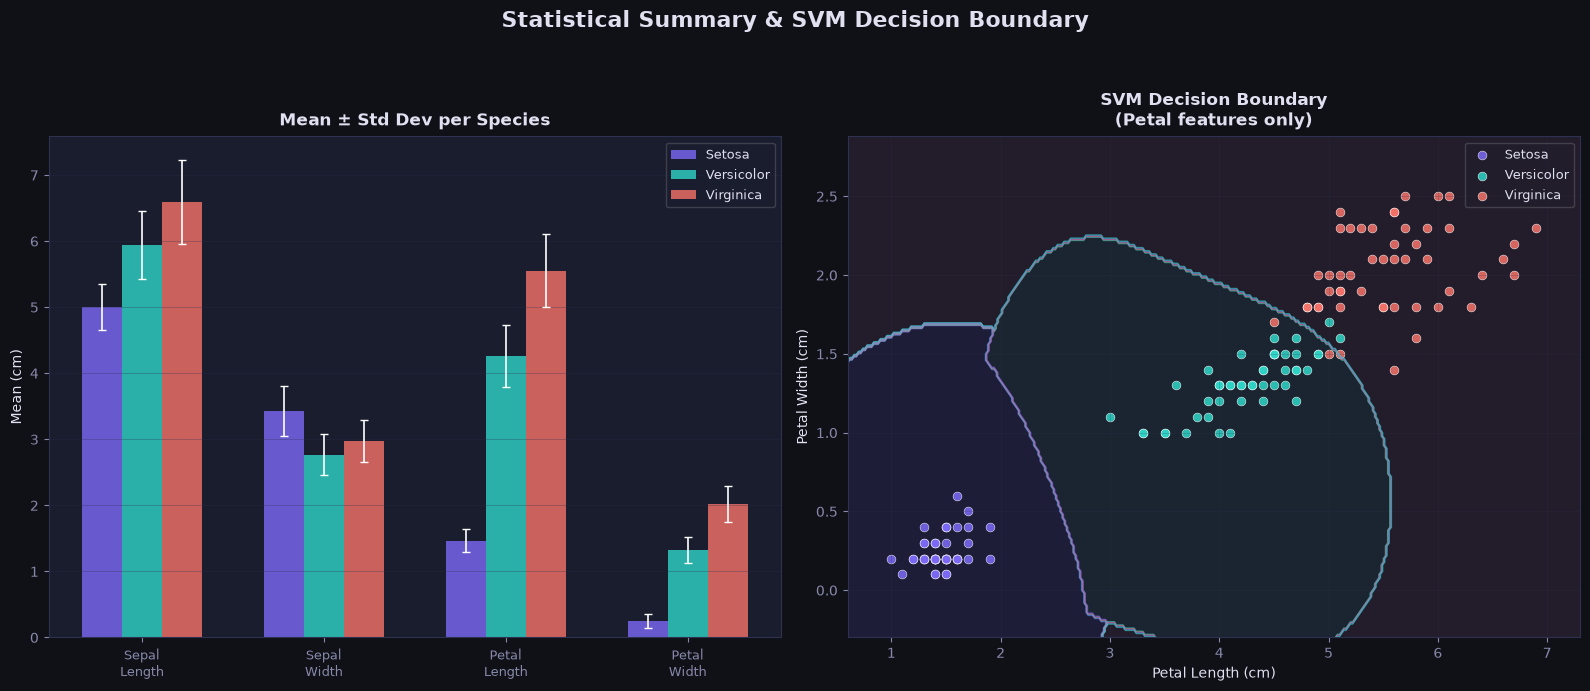

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#0f1117')
fig.suptitle('Statistical Summary & SVM Decision Boundary', fontsize=16,
             fontweight='bold', color='#e0e0f0')

# LEFT: grouped bar chart (mean ± std)
ax = axes[0]; ax.set_facecolor('#1a1d2e')
x = np.arange(4); w = 0.22
for i, (sp, col) in enumerate(zip(SPECIES, PALETTE)):
    sub   = df[df['species']==sp][FEATURES]
    means = sub.mean().values; stds = sub.std().values
    ax.bar(x + i*w, means, w, label=sp, color=col, alpha=0.8, edgecolor='none')
    ax.errorbar(x + i*w, means, yerr=stds, fmt='none',
                color='white', capsize=3, linewidth=1.2)
ax.set_xticks(x + w)
ax.set_xticklabels(['Sepal\nLength','Sepal\nWidth','Petal\nLength','Petal\nWidth'], fontsize=9)
ax.set_ylabel('Mean (cm)'); ax.set_title('Mean ± Std Dev per Species', fontweight='bold', pad=8)
ax.legend(fontsize=9, framealpha=0.2); ax.grid(True, axis='y', alpha=0.35)

# RIGHT: decision boundary
ax2 = axes[1]; ax2.set_facecolor('#1a1d2e')
X2 = df[['petal_length','petal_width']].values; y2 = iris.target
clf = SVC(kernel='rbf', C=5, gamma=0.8); clf.fit(X2, y2)
h = 0.02
xx, yy = np.meshgrid(np.arange(X2[:,0].min()-0.4, X2[:,0].max()+0.4, h),
                     np.arange(X2[:,1].min()-0.4, X2[:,1].max()+0.4, h))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
from matplotlib.colors import ListedColormap
ax2.contourf(xx, yy, Z, alpha=0.30, cmap=ListedColormap(['#2a1f4e','#1a3a3a','#3a1f25']))
ax2.contour(xx, yy, Z, colors=['#7c6af7','#2fd6c8','#f7736a'], linewidths=1.0, alpha=0.6)
for i, (sp, col) in enumerate(zip(SPECIES, PALETTE)):
    m = y2==i
    ax2.scatter(X2[m,0], X2[m,1], c=col, s=40, label=sp,
                alpha=0.85, edgecolors='white', linewidths=0.4)
ax2.set_xlabel('Petal Length (cm)'); ax2.set_ylabel('Petal Width (cm)')
ax2.set_title('SVM Decision Boundary\n(Petal features only)', fontweight='bold', pad=8)
ax2.legend(fontsize=9, framealpha=0.2); ax2.grid(True, alpha=0.25)

plt.tight_layout(rect=[0,0,1,0.94])
plt.savefig('iris_04_stats_decision.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 8. Advanced: Andrews Curves & RadViz
> These are rarely seen in Iris projects. Andrews Curves encode all 4 features into a Fourier series — species that separate cleanly show distinct wave bands.


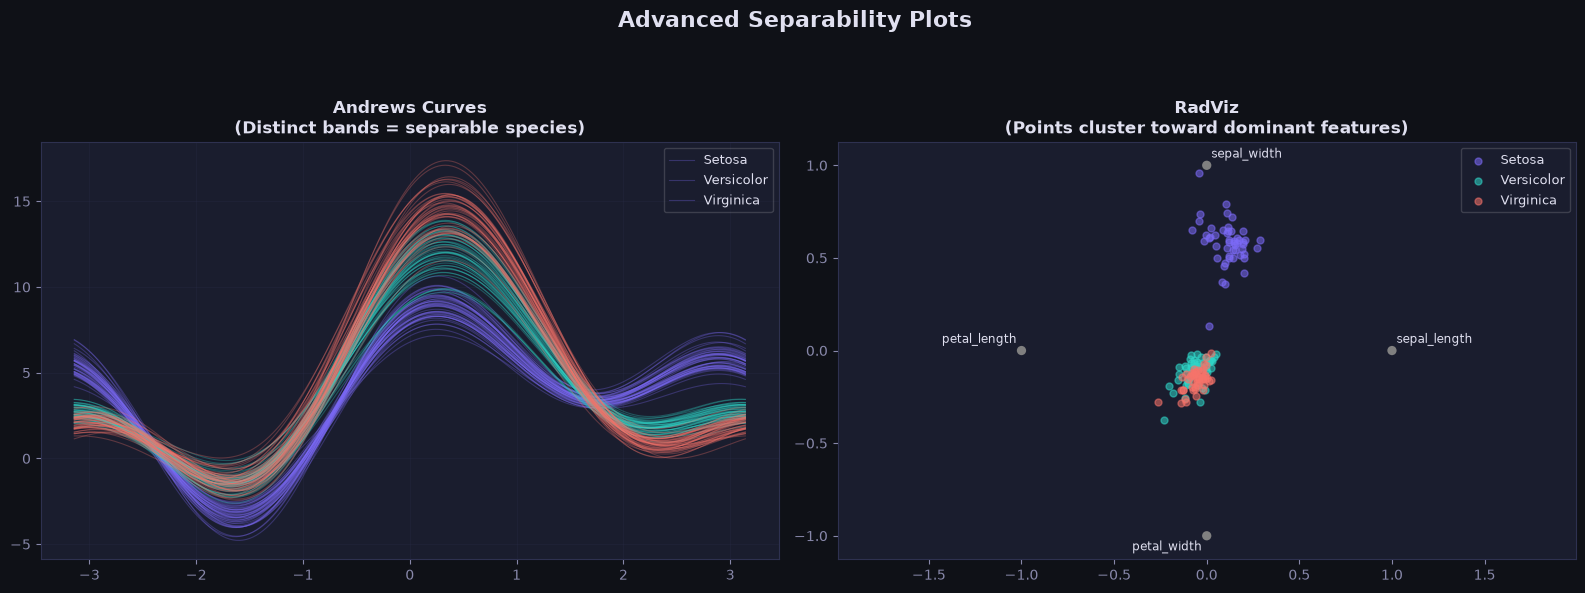

In [8]:
from pandas.plotting import andrews_curves, radviz

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0f1117')
fig.suptitle('Advanced Separability Plots', fontsize=16, fontweight='bold', color='#e0e0f0')

df_plot = df.copy()

ax1 = axes[0]; ax1.set_facecolor('#1a1d2e')
andrews_curves(df_plot, 'species', ax=ax1, color=PALETTE, alpha=0.3, linewidth=0.8)
ax1.set_title('Andrews Curves\n(Distinct bands = separable species)', fontweight='bold')
ax1.legend(SPECIES, fontsize=9, framealpha=0.2)
ax1.grid(True, alpha=0.25)
for spine in ax1.spines.values(): spine.set_edgecolor('#2e3150')

ax2 = axes[1]; ax2.set_facecolor('#1a1d2e')
radviz(df_plot, 'species', ax=ax2, color=PALETTE, alpha=0.55, s=25)
ax2.set_title('RadViz\n(Points cluster toward dominant features)', fontweight='bold')
ax2.legend(SPECIES, fontsize=9, framealpha=0.2)
for spine in ax2.spines.values(): spine.set_edgecolor('#2e3150')

plt.tight_layout(rect=[0,0,1,0.92])
plt.savefig('iris_05_separability.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 9. Key Findings Summary
```
FINDING 1: Zero null values — perfectly clean dataset (150 × 5)
FINDING 2: petal_length & petal_width have r=0.96 — nearly perfect correlation
FINDING 3: Setosa is linearly separable from Versicolor & Virginica on ALL features
FINDING 4: Versicolor & Virginica overlap slightly — need non-linear classifiers
FINDING 5: Best feature pair for classification: petal_length vs petal_width
FINDING 6: sepal_width has the most overlap between species — least discriminative
FINDING 7: SVM with RBF kernel draws clean boundaries with minimal misclassification
```

---
**Next → Phase 2:** Train KNN, Logistic Regression, SVM, Random Forest, XGBoost.  
Compare all on accuracy, precision, recall, F1 and confusion matrices.
